```markdown
# Semana 1 - Día 2: De la Matemática a Keras y la Red Multicapa
**Especialización en Ciencia de Datos e Inteligencia Artificial**

En la sesión anterior construimos una neurona artificial desde cero, calculando las derivadas y actualizando los pesos a mano para decidir si aprobábamos un crédito bancario.

Hoy vamos a dejar que **Keras** (una librería de Deep Learning construida sobre TensorFlow) haga todo ese trabajo pesado matemático por nosotros en unas pocas líneas de código. Luego, daremos el salto evolutivo: conectar varias neuronas para formar una **Red Neuronal Multicapa (MLP)**.

## 1. Preparación de los Datos (El mismo problema del banco)
Vamos a generar a nuestros clientes históricos igual que ayer: ingresos ($x_1$) e historial crediticio ($x_2$).

*Nota importante:* Ayer usamos etiquetas `-1` (rechazado) y `+1` (aprobado). En Keras, el estándar para clasificación binaria es usar probabilidades, por lo que usaremos **`0` (rechazado)** y **`1` (aprobado)**.

```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. GENERAMOS LOS DATOS (Igual que el Día 1)
np.random.seed(42)

# Clientes Rechazados (Etiqueta 0)
ingresos_rechazados = np.random.randn(20)
historial_rechazados = np.random.randn(20)
etiquetas_rechazados = np.zeros(20) # Ahora usamos 0 en lugar de -1

# Clientes Aprobados (Etiqueta 1)
ingresos_aprobados = np.random.randn(20) + 2.0
historial_aprobados = np.random.randn(20) + 2.0
etiquetas_aprobados = np.ones(20)

# Unimos los datos
X_clientes = np.column_stack((
    np.concatenate((ingresos_rechazados, ingresos_aprobados)),
    np.concatenate((historial_rechazados, historial_aprobados))
))
Y_etiquetas = np.concatenate((etiquetas_rechazados, etiquetas_aprobados))

print("Datos listos. Tenemos", len(Y_etiquetas), "clientes cargados.")

Datos listos. Tenemos 40 clientes cargados.


```markdown
## 2. Construyendo la Neurona en Keras
Ayer escribimos funciones manuales para la suma ponderada y la activación. Keras empaqueta todo esto en algo llamado **Capa Densa (`Dense`)**.

Se llama "densa" porque si hubiera más neuronas, todas estarían conectadas con todas. Como por ahora solo queremos recrear nuestro perceptrón simple del Día 1, usaremos una capa densa con **1 sola neurona**.

* **`units=1`**: Una sola neurona (nos dará 1 sola predicción final).
* **`input_dim=2`**: Recibe 2 variables (Ingreso e Historial).
* **`activation='sigmoid'`**: Nuestra función matemática. A diferencia de la función escalón que daba cortes bruscos, la curva sigmoide nos devuelve una probabilidad "suave" entre 0% y 100%.

```

In [ ]:
# Inicializamos el modelo (Sequential significa que las capas van una detrás de otra)
modelo_perceptron = Sequential()

# Agregamos nuestra neurona
modelo_perceptron.add(Dense(units=1, input_dim=2, activation='sigmoid'))

# Vemos un resumen de nuestra arquitectura
modelo_perceptron.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

```markdown
## 3. El Motor Matemático: Compilación y Entrenamiento
Ahora debemos decirle a Keras cómo queremos que la neurona aprenda. ¿Recuerdas el **Descenso del Gradiente** (la pelota bajando la montaña hacia el error mínimo)? Aquí lo configuramos.

* **`optimizer='sgd'`**: Stochastic Gradient Descent. Es el algoritmo matemático que actualiza los pesos automáticamente.
* **`loss='binary_crossentropy'`**: Es la fórmula matemática que calcula el Error cuando clasificamos entre dos opciones (0 y 1).

```

In [ ]:
# 1. COMPILAMOS (Configuramos el motor de aprendizaje)
modelo_perceptron.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# 2. ENTRENAMOS (El equivalente a nuestros bucles 'for' de ayer)
# epochs: cuántas veces repasará todos los datos de los clientes
print("Iniciando el entrenamiento...")
historial_aprendizaje = modelo_perceptron.fit(X_clientes, Y_etiquetas, epochs=2000, verbose=1)
print("¡Entrenamiento finalizado!")

Iniciando el entrenamiento...
Epoch 1/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9292 - loss: 0.2143 
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9187 - loss: 0.2246
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9187 - loss: 0.2228
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9187 - loss: 0.2294
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9292 - loss: 0.2069
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9292 - loss: 0.2138
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9187 - loss: 0.2242
Epoch 8/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9187 - loss: 0.2273
Epoch 9/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9187 - loss: 0.2300
Epoch 10/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9292 - loss: 0.2010
Epoch 11/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9187 - loss: 0.2229
Epoch 12/2000
2/2 ━━━━━━━━━━━━━━

```markdown
## 4. Visualizando el Aprendizaje
Ayer solo vimos el inicio y el final. Keras guarda el registro de cómo fue cayendo el error paso a paso en cada época. Vamos a graficar esa "montaña" descendiendo.

```

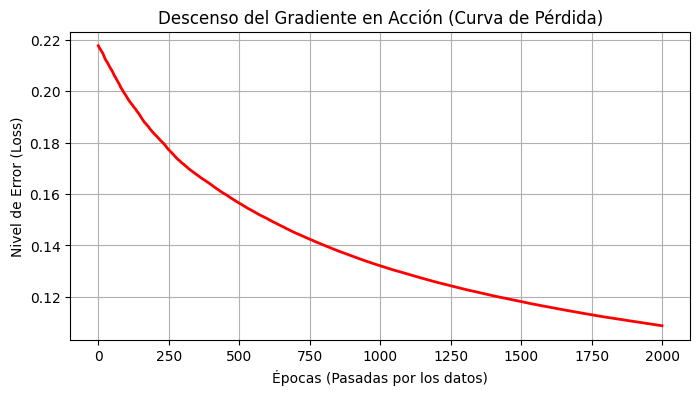

In [ ]:
# Extraemos el registro de errores
errores = historial_aprendizaje.history['loss']

plt.figure(figsize=(8,4))
plt.plot(errores, color='red', linewidth=2)
plt.title("Descenso del Gradiente en Acción (Curva de Pérdida)")
plt.xlabel("Épocas (Pasadas por los datos)")
plt.ylabel("Nivel de Error (Loss)")
plt.grid(True)
plt.show()